<a href="https://colab.research.google.com/github/halimaturrohmah-hub/Halimatur-Rohmah/blob/main/Jawaban_P6_UTS_Halimatur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A. Exploratory Data Analysis (EDA)

1.Memahami Dataset

Dataset IBM HR Employee Attrition digunakan untuk menganalisis faktor-faktor yang mempengaruhi pengunduran diri karyawan (attrition).

Jumlah data: 1470

Jumlah fitur: 35

Target variabel: Attrition

Yes = Karyawan mengundurkan diri

No = Karyawan tetap bekerja

Contoh fitur penting:
- Age
- MonthlyIncome
- JobRole
- DistanceFromHome
- JobSatisfaction
- WorkLifeBalance
- YearsAtCompany
- OverTime

2.Analisis Awal Data

a. Mengecek Missing Value

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('HR-Employee-Attrition.csv')

print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

Hasil:

- Dataset tidak memiliki missing value.
- Data sudah cukup bersih untuk dianalisis.

b. Distribusi Attrition

In [3]:
print(df['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


Interpretasi:

- Sebagian besar karyawan tidak mengundurkan diri.
- Dataset bersifat tidak seimbang (imbalanced).

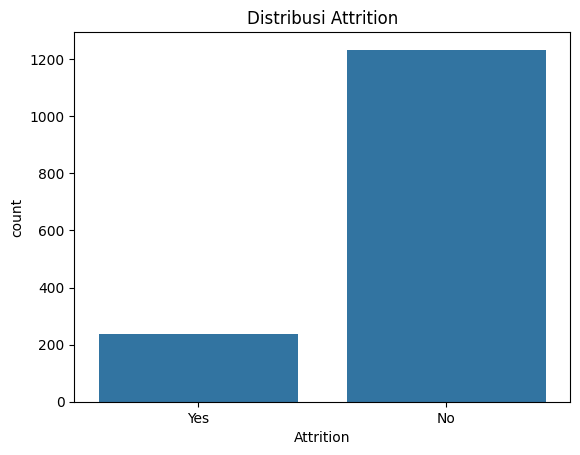

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Attrition', data=df)
plt.title('Distribusi Attrition')
plt.show()

Kesimpulan:

Jumlah karyawan bertahan lebih banyak dibanding yang keluar.

c. Pengaruh OverTime terhadap Attrition

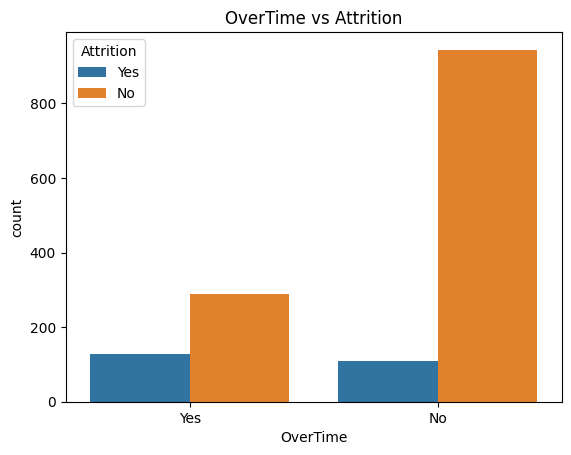

In [5]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('OverTime vs Attrition')
plt.show()

Analisis:

- Karyawan yang sering lembur (OverTime = Yes) lebih banyak mengundurkan diri.
- Lembur menjadi salah satu faktor utama attrition.

d. Monthly Income vs Attrition

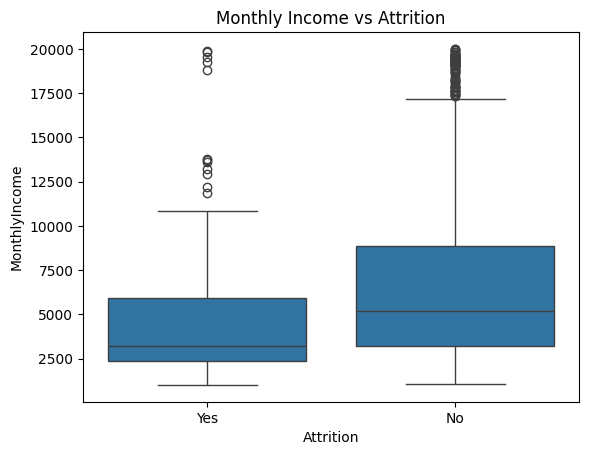

In [6]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.show()

Analisis:

- Karyawan dengan pendapatan lebih rendah cenderung lebih banyak keluar.
- Pendapatan dapat mempengaruhi kepuasan kerja.

e. Distance From Home vs Attrition

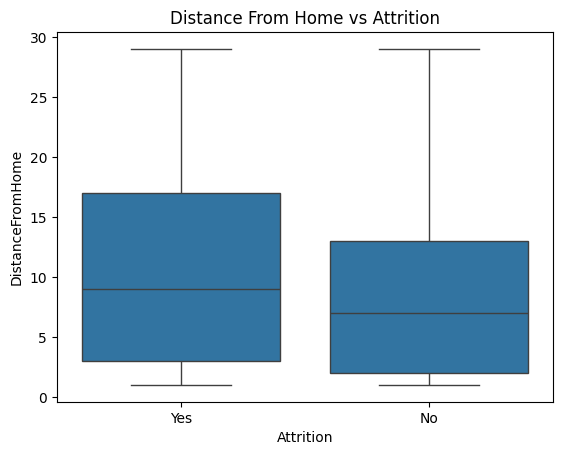

In [7]:
sns.boxplot(x='Attrition', y='DistanceFromHome', data=df)
plt.title('Distance From Home vs Attrition')
plt.show()

Analisis:

- Karyawan yang rumahnya lebih jauh cenderung memiliki tingkat attrition lebih tinggi.
- Faktor jarak mempengaruhi kenyamanan kerja.

f. Job Satisfaction vs Attrition

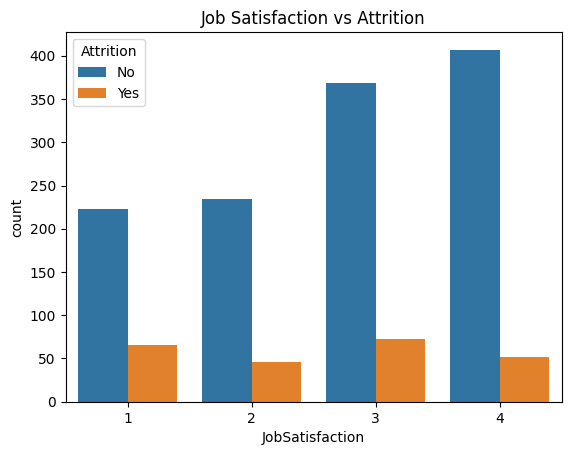

In [8]:
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title('Job Satisfaction vs Attrition')
plt.show()

Analisis:

Semakin rendah kepuasan kerja, semakin tinggi kemungkinan resign.

g. Korelasi Antar Variabel Numerik

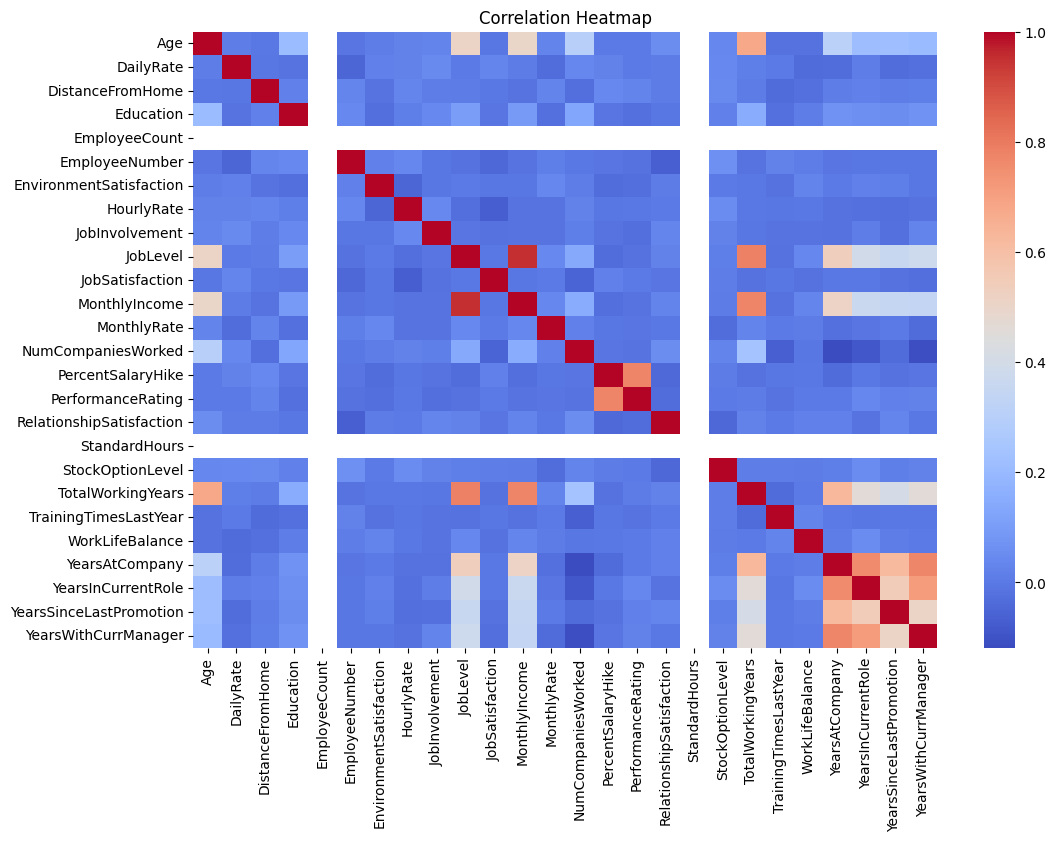

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Analisis:

- MonthlyIncome berkorelasi dengan JobLevel dan TotalWorkingYears.
- YearsAtCompany berkorelasi dengan YearsInCurrentRole.

B. Rekayasa Fitur dan Pengkodean Kategorikal

Encoding Variabel Target

In [23]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Re-load the dataset to ensure df is in a clean state, addressing the corrupted 'Attrition' column
df = pd.read_csv('HR-Employee-Attrition.csv')

# Re-apply column dropping based on previous steps
columns_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1)

# Re-apply Label Encoding for categorical columns, excluding 'Attrition'
le = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'Attrition' in categorical_cols:
    categorical_cols.remove('Attrition') # Attrition will be mapped manually

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Now, perform the Attrition mapping from 'Yes'/'No' to 1/0
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

# Ensure the column is of integer type after mapping
df['Attrition'] = df['Attrition'].astype(int)

Label Encoding

- Digunakan untuk fitur kategorikal ordinal.

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Feature Scaling

- Dilakukan agar skala data lebih stabil.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_scaled = scaler.fit_transform(X)

C. Implementasi Machine Learning

1. Split Data

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

2. Menggunakan Random Forest Classifier

Model Random Forest dipilih karena:
- Cocok untuk klasifikasi
- Mampu menangani banyak fitur
- Dapat melihat feature importance
- Akurasi cukup baik

In [26]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

3. Prediksi dan Evaluasi

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Instantiate and fit the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8809523809523809
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88      0.88      0.84       294



Visualisasi confusion matrix:

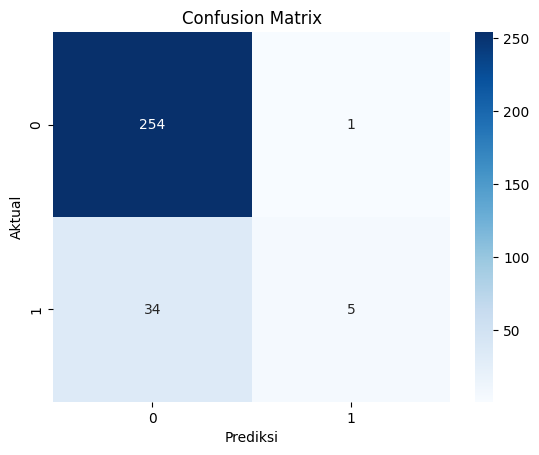

In [29]:
import seaborn as sns

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

Hasil dan Interpretasi

Berdasarkan analisis dan model machine learning, beberapa faktor utama yang mempengaruhi pengunduran diri karyawan adalah:

1.OverTime
- Karyawan yang sering lembur lebih rentan resign.

2.MonthlyIncome
- Pendapatan rendah meningkatkan kemungkinan attrition.

3.JobSatisfaction
- Kepuasan kerja rendah berkaitan erat dengan resign.

4.DistanceFromHome
- Jarak rumah yang jauh mempengaruhi tingkat attrition.

5.WorkLifeBalance
- Ketidakseimbangan kehidupan kerja meningkatkan stres kerja.

6.YearsAtCompany
- Karyawan baru lebih berpotensi mengundurkan diri dibanding yang sudah lama bekerja.